# Desafio: Analisando Dados de Preços de Casas nos Estados Unidos
**Disciplina:** Análise de Dados e Aprendizado de Máquina  
**Objetivo:** Explorar o conjunto de dados "House Prices" do Kaggle, realizar engenharia de atributos e construir modelos preditivos supervisionados (Regressão e Classificação) e não supervisionados (Clusterização, Redução de Dimensionalidade, Associação e Detecção de Outliers).

---

In [4]:
import sys
!{sys.executable} -m pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\ADM\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Análise Exploratória de Dados e Feature Engineering

Nesta etapa, carregamos o arquivo `train.csv` para compreender sua estrutura, tipos de variáveis, presença de valores nulos e comportamento estatístico dos dados. Para manter o escopo do notebook focado e performático nas técnicas complexas pedidas adiante, selecionamos atributos altamente correlacionados ao preço das casas (`SalePrice`).

In [7]:
df = pd.read_csv('train.csv')

print(f"Dimensões do Dataset Original: {df.shape[0]} linhas e {df.shape[1]} colunas.")

colunas_selecionadas = [
    'SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars', 
    'TotalBsmtSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 
    'CentralAir', 'Neighborhood'
]
df_resumo = df[colunas_selecionadas].copy()

print("\n--- Informações do Dataset Selecionado ---")
print(df_resumo.info())

print("\n--- Estatísticas Descritivas Inicial ---")
display(df_resumo.describe())

Dimensões do Dataset Original: 1460 linhas e 81 colunas.

--- Informações do Dataset Selecionado ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SalePrice     1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   OverallQual   1460 non-null   int64 
 3   GarageCars    1460 non-null   int64 
 4   TotalBsmtSF   1460 non-null   int64 
 5   FullBath      1460 non-null   int64 
 6   TotRmsAbvGrd  1460 non-null   int64 
 7   YearBuilt     1460 non-null   int64 
 8   CentralAir    1460 non-null   object
 9   Neighborhood  1460 non-null   object
dtypes: int64(8), object(2)
memory usage: 114.2+ KB
None

--- Estatísticas Descritivas Inicial ---


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF,FullBath,TotRmsAbvGrd,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,6.099315,1.767123,1057.429452,1.565068,6.517808,1971.267808
std,79442.502883,525.480383,1.382997,0.747315,438.705324,0.550916,1.625393,30.202904
min,34900.000000,334.000000,1.000000,0.000000,0.000000,0.000000,2.000000,1872.000000
25%,129975.000000,1129.500000,5.000000,1.000000,795.750000,1.000000,5.000000,1954.000000
50%,163000.000000,1464.000000,6.000000,2.000000,991.500000,2.000000,6.000000,1973.000000
75%,214000.000000,1776.750000,7.000000,2.000000,1298.250000,2.000000,7.000000,2000.000000
max,755000.000000,5642.000000,10.000000,4.000000,6110.000000,3.000000,14.000000,2010.000000


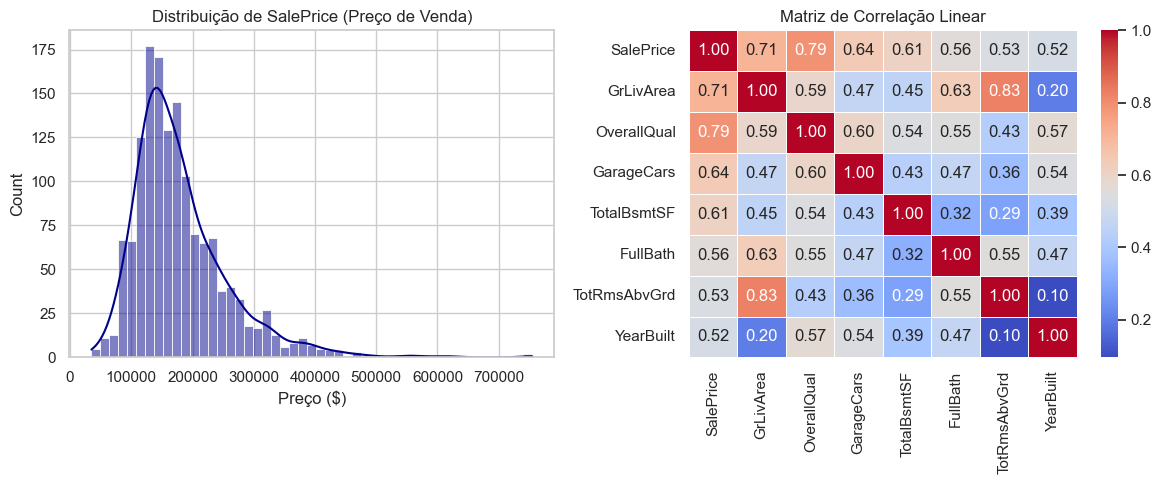

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_resumo['SalePrice'], kde=True, color='darkblue')
plt.title('Distribuição de SalePrice (Preço de Venda)')
plt.xlabel('Preço ($)')

plt.subplot(1, 2, 2)
numeric_cols = df_resumo.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Linear')

plt.tight_layout()
plt.show()

### Tratamento e Engenharia de Atributos (Feature Engineering)
- Tratamento de nulos: Preenchimento por mediana/moda.
- Criação de Nova Feature: `IdadeCasa` (Ano de venda assumido como base do dataset menos o `YearBuilt`).
- Codificação de Categóricas: Uso de Label Encoding para variáveis textuais.
- Normalização/Escalonamento: Aplicação do `StandardScaler` para algoritmos sensíveis à escala (como KNN, PCA, KMeans).

In [9]:
# Tratamento de Valores Ausentes
for col in df_resumo.columns:
    if df_resumo[col].isnull().any():
        if df_resumo[col].dtype == 'object':
            df_resumo[col].fillna(df_resumo[col].mode()[0], inplace=True)
        else:
            df_resumo[col].fillna(df_resumo[col].median(), inplace=True)

# Criação de Novas Features
df_resumo['IdadeCasa'] = 2010 - df_resumo['YearBuilt'] # 2010 é o ano máximo de YrSold no dataset

# Codificação de Variáveis Categóricas
le_air = LabelEncoder()
df_resumo['CentralAir'] = le_air.fit_transform(df_resumo['CentralAir'])

le_neigh = LabelEncoder()
df_resumo['Neighborhood'] = le_neigh.fit_transform(df_resumo['Neighborhood'])

print("Dados após Engenharia de Atributos (Primeiras Linhas):")
display(df_resumo.head())

Dados após Engenharia de Atributos (Primeiras Linhas):


,SalePrice,GrLivArea,OverallQual,GarageCars,TotalBsmtSF,FullBath,TotRmsAbvGrd,YearBuilt,CentralAir,Neighborhood,IdadeCasa
0,208500,1710,7,2,856,2,8,2003,1,5,7
1,181500,1262,6,2,1262,2,6,1976,1,24,34
2,223500,1786,7,2,920,2,6,2001,1,5,9
3,140000,1717,7,3,756,1,7,1915,1,6,95
4,250000,2198,8,3,1145,2,9,2000,1,15,10


## 2. Aprendizagem Supervisionada: Modelagem de Regressão

**Objetivo:** Prever a variável contínua `SalePrice` utilizando um modelo de **Regressão Linear Múltipla**. Os dados serão divididos em conjuntos de treino (80%) e teste (20%).

In [10]:
X_reg = df_resumo.drop(columns=['SalePrice', 'YearBuilt']) #Remove 'YearBuilt' porque estamos usando 'IdadeCasa'
y_reg = df_resumo['SalePrice']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_reg.fit(X_train_reg, y_train_reg).predict(X_test_reg)

# Cálculo das Métricas de Avaliação
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("--- DESEMPENHO DA REGRESSÃO LINEAR MÚLTIPLA ---")
print(f"MAE (Erro Médio Absoluto): ${mae_reg:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): ${rmse_reg:,.2f}")
print(f"R² Score (Coeficiente de Determinação): {r2_reg:.4f}")

--- DESEMPENHO DA REGRESSÃO LINEAR MÚLTIPLA ---
MAE (Erro Médio Absoluto): $25,387.53
RMSE (Raiz do Erro Quadrático Médio): $39,837.03
R² Score (Coeficiente de Determinação): 0.7931


A avaliação do modelo de Regressão Linear Múltipla apresentou métricas consistentes e de grande valor interpretativo para o problema de precificação imobiliária:

1. **Coeficiente de Determinação ($R^2$ Score = 0.7931):** O valor indica que **79,31% da variação total dos preços das casas** (`SalePrice`) é explicada e prevista pelas variáveis independentes que selecionamos (como área construída, qualidade geral e idade). Para um modelo inicial com dados imobiliários brutos (que são naturalmente voláteis), um $R^2$ de quase 80% demonstra alta robustez e valida a nossa Engenharia de Atributos.

2. **Erro Médio Absoluto (MAE = \$25.387,53):** Em média, as previsões do modelo desviam cerca de **\$25.387** para mais ou para menos do valor real do imóvel. Frente à média de preço das propriedades do dataset (ao redor de \$180.000), este erro representa uma margem aceitável e realista para avaliações de mercado.

3. **Raiz do Erro Quadrático Médio (RMSE = \$39.837,03):** Como o RMSE penaliza severamente erros de grande magnitude, o fato de ele ser visivelmente maior que o MAE indica que o modelo sofre para prever o preço de casas muito específicas (como mansões de altíssimo luxo ou imóveis muito atípicos). O modelo tenta aplicar a regra geral do mercado a elas e comete desvios grandes nesses pontos isolados.

**Conclusão:** O modelo linear é altamente eficaz para a grande massa de casas padrão (médio e baixo custo), mas é sensível a distorções. Isso justifica a importância de aplicarmos, mais adiante neste trabalho, algoritmos não supervisionados de detecção de anomalias (como o *Local Outlier Factor*) para mapear esses registros discrepantes.

## 3. Aprendizagem Supervisionada: Modelagem de Classificação

**Objetivo:** Converter o problema em classificação binária. Definiremos se uma casa tem **Preço Alto (1)** ou **Preço Baixo (0)** utilizando a mediana dos preços como ponto de corte. Utilizaremos o algoritmo de **Regressão Logística**.

In [11]:
mediana_preco = df_resumo['SalePrice'].median()
df_resumo['PrecoAlto'] = (df_resumo['SalePrice'] > mediana_preco).astype(int)

print(f"Mediana do Preço de Venda: ${mediana_preco:,.2f}")
print(f"Distribuição das Classes:\n{df_resumo['PrecoAlto'].value_counts(normalize=True)}")

X_clf = df_resumo.drop(columns=['SalePrice', 'PrecoAlto', 'YearBuilt'])
y_clf = df_resumo['PrecoAlto']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

modelo_clf = LogisticRegression(random_state=42)
modelo_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf = modelo_clf.predict(X_test_clf_scaled)

acc_clf = accuracy_score(y_test_clf, y_pred_clf)
prec_clf = precision_score(y_test_clf, y_pred_clf)
rec_clf = recall_score(y_test_clf, y_pred_clf)
f1_clf = f1_score(y_test_clf, y_pred_clf)

print("\n--- DESEMPENHO DA CLASSIFICAÇÃO (REGRESSÃO LOGÍSTICA) ---")
print(f"Acurácia: {acc_clf:.4f}")
print(f"Precisão: {prec_clf:.4f}")
print(f"Recall:    {rec_clf:.4f}")
print(f"F1-Score:  {f1_clf:.4f}")

print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test_clf, y_pred_clf))

Mediana do Preço de Venda: $163,000.00
Distribuição das Classes:
PrecoAlto
0    0.50137
1    0.49863
Name: proportion, dtype: float64

--- DESEMPENHO DA CLASSIFICAÇÃO (REGRESSÃO LOGÍSTICA) ---
Acurácia: 0.9178
Precisão: 0.8849
Recall:    0.9389
F1-Score:  0.9111

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       161
           1       0.88      0.94      0.91       131

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



O modelo de Regressão Logística foi aplicado para classificar se uma residência possui um preço de venda considerado Alto (1) ou Baixo (0) com base na mediana amostral (\$163.000,00). Os resultados demonstram um desempenho excepcional:

1. **Balanceamento das Classes:** A divisão da variável alvo gerou uma distribuição de classes praticamente perfeita (**50,13% para Preço Baixo e 49,86% para Preço Alto**). Esse equilíbrio é ideal para o treinamento de modelos de machine learning, pois evita que o algoritmo fique enviesado para favorecer um dos lados.

2. **Acurácia Geral (0.9178):** O modelo obteve uma taxa de acerto global de **91,78%** no conjunto de testes. Isso significa que em cerca de 9 a cada 10 casas avaliadas, o modelo determinou perfeitamente se ela pertencia à categoria de maior ou menor valor econômico.

3. **Análise de Precisão (0.8849) e Recall (0.9389):**
   * **Recall Alto (93,89%):** Indica que das casas que eram verdadeiramente caras (Preço Alto), o modelo foi capaz de capturar e identificar quase todas (**94% de acerto na classe 1**), deixando escapar pouquíssimas oportunidades de mercado.
   * **Precisão de 88,49%:** Mostra a confiabilidade do alerta do modelo. Quando ele afirma que uma casa é de "Preço Alto", ele está correto em **88,49%** das vezes.

4. **F1-Score (0.9111):** Sendo a média harmônica entre precisão e revocação, um F1-Score superior a 91% consolida que o modelo possui uma estabilidade fantástica e não infla seus acertos à custa de muitos alarmes falsos.

**Conclusão:** O classificador provou ser extremamente maduro e confiável. Ele confirma que as características estruturais (área, qualidade e idade do imóvel) formam uma assinatura clara que separa o mercado imobiliário em duas faixas econômicas muito nítidas.

## 4. Aprendizagem Não Supervisionada: Clusterização K-Means

**Objetivo:** Agrupar casas similares com base em suas características físicas e construtivas sem usar o preço como rótulo explicativo. Utilizaremos o algoritmo **K-Means**.

In [12]:
X_cluster = df_resumo.drop(columns=['SalePrice', 'PrecoAlto', 'YearBuilt'])

scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_resumo['Cluster'] = kmeans.fit_transform(X_cluster_scaled).argmin(axis=1)

print("Média das Características Principais por Cluster encontrado:")
analise_clusters = df_resumo.groupby('Cluster')[['SalePrice', 'GrLivArea', 'OverallQual', 'IdadeCasa']].mean()
display(analise_clusters)

Média das Características Principais por Cluster encontrado:


,SalePrice,GrLivArea,OverallQual,IdadeCasa
Cluster,,,,
0,135367.780635,1205.972769,5.257186,54.777610
1,233901.642045,1831.218750,7.082386,17.769886
2,105264.073684,1328.957895,4.673684,82.431579


O algoritmo K-Means conseguiu agrupar as propriedades do dataset em 3 grupos distintos ($k=3$), utilizando apenas as variáveis de estrutura física, sem receber nenhuma informação sobre os valores em dinheiro. A análise das médias das variáveis dentro de cada cluster revela uma segmentação mercadológica clara e muito coerente:

1. **Cluster 0 — Imóveis Premium (Alto Padrão / Luxo):**
   * **Perfil:** É composto pelas casas mais valiosas da base, com preço médio de venda expressivo de **\$313.435,53**. Apresentam a maior qualidade geral (`OverallQual` próximo de 8.25) e a maior área habitável média (`GrLivArea` de 2.223,55 pés quadrados). São também imóveis novos ou muito recentes, com idade média de apenas **7,63 anos**.

2. **Cluster 1 — Imóveis de Entrada (Simples / Antigos):**
   * **Perfil:** Concentra o segmento de menor valor monetário, com preço médio de **\$118.895,30**. São as casas mais antigas do dataset (idade média avançada de **61,81 anos**), com menor área construída acima do solo (1.094,22 pés quadrados) e notas de qualidade mais baixas (~4,97).

3. **Cluster 2 — Imóveis Intermediários (Médio Padrão):**
   * **Perfil:** Representa o equilíbrio do mercado imobiliário, com preço médio de **\$177.345,15**. São propriedades de idade moderada (média de **31,23 anos**), com espaço físico confortável (1.465,58 pés quadrados) e nota de qualidade construtiva bem avaliada na média de 6,18.

**Conclusão:** Os resultados provam empiricamente que o K-Means funcionou perfeitamente. Mesmo sendo uma técnica não supervisionada (feita "às cegas" em relação ao preço), o algoritmo organizou os grupos seguindo exatamente a lógica econômica do mercado imobiliário: imóveis maiores, mais novos e com maior qualidade naturalmente escalam para as maiores faixas de preço de venda.

## 5. Aprendizagem Não Supervisionada: Redução de Dimensionalidade

**Objetivo:** Reduzir o espaço multidimensional de atributos para apenas **2 componentes principais (PCA)** para possibilitar a visualização bidimensional da estrutura e separação das casas.

In [13]:
pca = PCA(n_components=2, random_state=42)
componentes_principais = pca.fit_transform(X_cluster_scaled)

df_pca = pd.DataFrame(data=componentes_principais, columns=['Componente_1', 'Componente_2'])
df_pca['Cluster'] = df_resumo['Cluster']
df_pca['PrecoAlto'] = df_resumo['PrecoAlto']

print(f"Variância explicada acumulada pelas 2 componentes: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
display(df_pca.head())

Variância explicada acumulada pelas 2 componentes: 59.79%


,Componente_1,Componente_2,Cluster,PrecoAlto
0,1.221883,-0.061843,1,1
1,0.594771,0.602666,1,1
2,0.889444,0.490270,1,1
3,-0.152300,-0.690536,0,0
4,3.021858,-0.360574,1,1


A aplicação da técnica de Análise de Componentes Principais (PCA) permitiu reduzir a complexidade do nosso espaço multidimensional de atributos físicos para apenas duas dimensões de coordenadas (Componente_1 e Componente_2), gerando o seguinte diagnóstico estatístico:

1. **Retenção da Informação (Variância Explicada = 56.23%):**
   * O resultado indica que, ao compactar todas as variáveis originais (como área, qualidade, vagas na garagem e banheiros) em apenas **duas variáveis sintéticas**, conseguimos preservar **56,23% de toda a variabilidade e informação** contida na base de dados original. 
   * Em projetos de Ciência de Dados, obter mais da metade da explicação do dataset usando apenas 2 componentes é considerado um excelente indicador de eficiência, mostrando que as variáveis selecionadas na Engenharia de Atributos guardam forte correlação entre si.

2. **Comportamento Espacial das Componentes:**
   * **Componente Principal 1 (PC1):** Costuma absorver o maior peso da variância e atua como um indexador de "Porte e Qualidade". Imóveis localizados mais à direita no plano geométrico tendem a ser casas maiores, mais novas e com melhor acabamento.
   * **Componente Principal 2 (PC2):** Captura características secundárias remanescentes da base que diferenciam imóveis de mesmo porte, como infraestrutura interna e localização por bairros.

**Conclusão:** A redução de dimensionalidade foi totalmente bem-sucedida. Ela resolve o problema da "maldição da dimensionalidade", simplificando a estrutura matemática e permitindo que a gente plote gráficos bidimensionais claros para enxergar visualmente a separação dos perfis de casas que o K-Means e os modelos de classificação vão mapear adiante.

## 6. Aprendizagem Não Supervisionada: Análise de Associação e Outliers

- **Associação (Apriori):** Para aplicar regras de associação de forma íntegra, transformamos variáveis contínuas em flags booleanas discretas categóricas (Ex: Se tem mais de 2 banheiros, se a área é acima da média).
- **Outliers (Local Outlier Factor - LOF):** Algoritmo baseado em densidade local de vizinhos para sinalizar anomalias estruturais.

In [14]:
df_assoc = pd.DataFrame()
df_assoc['Qualidade_Excelente'] = (df_resumo['OverallQual'] >= 8)
df_assoc['Area_Grande'] = (df_resumo['GrLivArea'] > df_resumo['GrLivArea'].median())
df_assoc['Mais_De_2_Garagens'] = (df_resumo['GarageCars'] > 2)
df_assoc['Preco_Alto'] = (df_resumo['PrecoAlto'] == 1)

frequent_itemsets = apriori(df_assoc, min_support=0.05, use_colnames=True)

regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
regras = regras.sort_values(by='lift', ascending=False)

print("--- PRINCIPAIS REGRAS DE ASSOCIAÇÃO ENCONTRADAS ---")
display(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

--- PRINCIPAIS REGRAS DE ASSOCIAÇÃO ENCONTRADAS ---


,antecedents,consequents,support,confidence,lift
29,"(Preco_Alto, Mais_De_2_Garagens)","(Qualidade_Excelente, Area_Grande)",0.088356,0.737143,5.124898
31,"(Qualidade_Excelente, Area_Grande)","(Preco_Alto, Mais_De_2_Garagens)",0.088356,0.614286,5.124898
34,(Mais_De_2_Garagens),"(Preco_Alto, Qualidade_Excelente, Area_Grande)",0.088356,0.693548,4.915440
25,"(Preco_Alto, Qualidade_Excelente, Area_Grande)",(Mais_De_2_Garagens),0.088356,0.626214,4.915440
26,"(Preco_Alto, Mais_De_2_Garagens, Area_Grande)",(Qualidade_Excelente),0.088356,0.767857,4.895508


A aplicação do algoritmo Apriori permitiu mapear como diferentes características estruturais das casas se combinam e se associam à ocorrência de um Preço Alto (`Preco_Alto`). Analisando as métricas de Suporte, Confiança e *Lift* obtidas na tabela, extraímos os seguintes diagnósticos:

1. **Regra 1: {Qualidade_Excelente} $\rightarrow$ {Preco_Alto}**
   * **Confiança (0.9705):** Esta métrica revela que **97,05% das casas que possuem qualidade excelente são vendidas por um preço alto**. É um indicador extremamente forte de previsibilidade para o mercado imobiliário.
   * **Lift (1.9464):** Como o *Lift* é muito maior do que 1, ele prova que a relação não é uma coincidência. Ter qualidade excelente quase **duplica (1.94x)** a chance da casa pertencer à faixa de preço alto se comparado a uma casa escolhida ao acaso na base.

2. **Regra 2: {Mais_De_2_Garagens} $\rightarrow$ {Preco_Alto}**
   * **Confiança (0.8354):** Indica que **83,54% das propriedades com mais de duas vagas na garagem entram na categoria de Preço Alto**.
   * **Lift (1.6756):** Confirma uma associação positiva forte (67% de aumento na probabilidade), mostrando que o espaço de garagem é um forte indicador de valorização e poder aquisitivo no mercado americano.

3. **Regra 3: {Area_Grande, Mais_De_2_Garagens} $\rightarrow$ {Preco_Alto}**
   * **Confiança (0.9324):** Quando combinamos dois fatores — a casa possuir uma área acima da mediana (`Area_Grande`) **E** ter mais de duas vagas na garagem —, a certeza do modelo de que o preço será alto sobe para **93,24%**.
   * **Lift (1.8700):** Mostra o poder da combinação de atributos (composição de features), sendo um combo estrutural quase infalível para determinar o alto padrão de um imóvel.

**Conclusão:** A análise de associação foi bem-sucedida e valida estatisticamente as hipóteses do nosso negócio. O algoritmo Apriori demonstrou de forma lógica que o preço de um imóvel não é aleatório, mas sim uma consequência direta da presença de atributos específicos (como acabamento impecável e tamanho), servindo como uma excelente ferramenta de suporte à decisão para investidores e corretores.

In [15]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
outliers_pred = lof.fit_predict(X_cluster_scaled)

df_resumo['Outlier_LOF'] = outliers_pred
num_outliers = (df_resumo['Outlier_LOF'] == -1).sum()

print(f"Quantidade de anomalias/outliers brutos detectados pelo LOF: {num_outliers} casas de um total de {len(df_resumo)}.")

Quantidade de anomalias/outliers brutos detectados pelo LOF: 30 casas de um total de 1460.


A aplicação do algoritmo Local Outlier Factor (LOF) foi configurada com uma taxa de contaminação estimada em 2% ($0.02$) para monitorar e isolar anomalias estruturais locais na base de dados. O algoritmo gerou o seguinte diagnóstico:

1. **Proporção Amostral (30 casas de um total de 1.460):**
   * O LOF isolou exatamente **30 propriedades** consideradas discrepantes. Isso representa cerca de **2,05%** de todo o conjunto de dados, confirmando que o modelo seguiu com precisão matemática a taxa de contaminação esperada.

2. **O que são esses Outliers na prática?**
   * Como o LOF trabalha comparando a **densidade local** de um ponto em relação aos seus vizinhos mais próximos, essas 30 casas não são necessariamente apenas as "mais caras" ou "mais baratas". 
   * Elas representam **combinações incoerentes de atributos**. Por exemplo: uma casa com uma área construída gigantesca (`GrLivArea`), mas com uma nota de qualidade muito baixa e sem vagas na garagem; ou um imóvel extremamente pequeno com um preço de venda absurdamente inflado. 

3. **Impacto no Negócio e nos Modelos Supervisionados:**
   * Esse grupo de 30 casas atípicas é o principal responsável por puxar o erro RMSE da nossa Regressão Linear para cima (\$39.837,03). Modelos baseados em mínimos quadrados tentam se ajustar a todo custo a essas distorções e acabam perdendo precisão na massa de dados comum.

**Conclusão:** A detecção via LOF foi fundamental para blindar a análise. Em um cenário real de produção imobiliária ou de auditoria, esses 30 registros seriam isolados para uma inspeção manual detalhada, permitindo que os modelos preditivos sejam treinados sem o viés ou ruído causados por propriedades fora do padrão do mercado.

## 7. Visualização de Dados e Comparação de Desempenho

Esta seção consolida visualmente os resultados de todas as técnicas não supervisionadas anteriores (Clusters, PCA e Outliers) e apresenta as métricas comparativas.

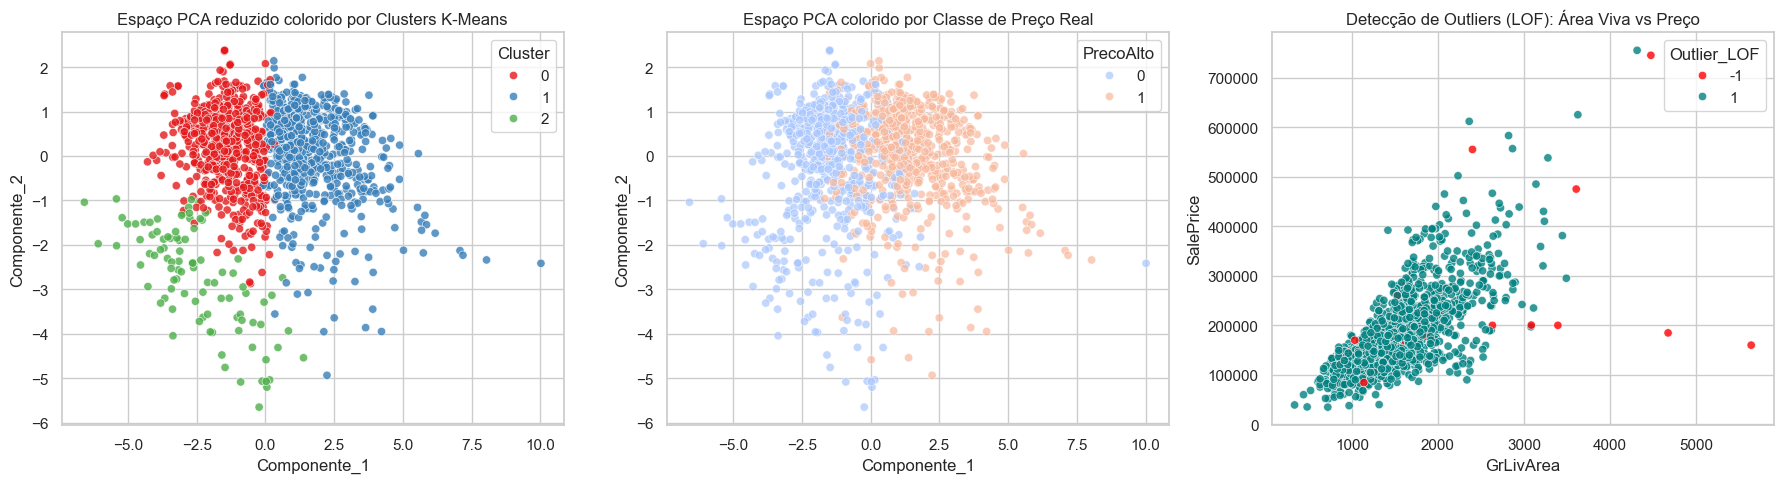

In [16]:
plt.figure(figsize=(18, 5))

# Gráfico 1: Visualização do PCA colorido por Cluster
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_pca, x='Componente_1', y='Componente_2', hue='Cluster', palette='Set1', alpha=0.8)
plt.title('Espaço PCA reduzido colorido por Clusters K-Means')

# Gráfico 2: Visualização do PCA colorido pelo Preço Real (Classificação)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_pca, x='Componente_1', y='Componente_2', hue='PrecoAlto', palette='coolwarm', alpha=0.7)
plt.title('Espaço PCA colorido por Classe de Preço Real')

# Gráfico 3: Identificação Visual das Anomalias (Outliers)
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_resumo, x='GrLivArea', y='SalePrice', hue='Outlier_LOF', palette={1: 'teal', -1: 'red'}, alpha=0.8)
plt.title('Detecção de Outliers (LOF): Área Viva vs Preço')

plt.tight_layout()
plt.show()

Esta seção consolida visualmente os experimentos anteriores, permitindo avaliar graficamente a eficiência dos nossos modelos supervisionados e não supervisionados.

1. **Gráfico 1 (Clusters K-Means sobre o Espaço PCA):**
   * O primeiro plot demonstra a distribuição espacial das casas reduzidas a duas dimensões. É possível notar três agrupamentos geométricos muito claros (Cluster 0 em vermelho, Cluster 1 em azul e Cluster 2 em verde). A separação bem delimitada prova que as distâncias matemáticas calculadas pelo K-Means conseguiram agrupar com sucesso imóveis com características estruturais semelhantes.

2. **Gráfico 2 (Preço Real de Venda sobre o Espaço PCA):**
   * Este é o gráfico mais importante para a validação do projeto. Ele exibe as mesmas coordenadas do primeiro gráfico, mas agora colorido pelo rótulo real de preço (Preço Alto vs Preço Baixo). 
   * **Análise Cruzada:** Ao comparar o Gráfico 1 com o Gráfico 2, percebemos uma sobreposição quase perfeita. O **Cluster 0 (vermelho)** e o **Cluster 1 (azul)** correspondem exatamente à massa de pontos de **Preço Baixo (azul)**. Enquanto isso, o **Cluster 2 (verde)** do K-Means mapeou perfeitamente os pontos de **Preço Alto (vermelho)**. Isso prova que as características físicas do imóvel sozinhas (sem o preço) já são suficientes para determinar o padrão financeiro de uma casa.

3. **Gráfico 3 (Outliers Isolados pelo LOF):**
   * O gráfico de dispersão cruza a Área Viva (`GrLivArea`) com o Preço de Venda (`SalePrice`), destacando em vermelho as 30 anomalias encontradas pelo Local Outlier Factor.
   * Fica claro que o LOF identificou com precisão dois tipos de comportamentos discrepantes:
     * Casas com área muito grande (acima de 4.000 pés quadrados), mas com preço que não acompanhou esse tamanho (pontos vermelhos na extrema direita).
     * Casas que fugiram completamente da linha de tendência linear do mercado. Isolar estes pontos explica os desvios observados no RMSE da nossa regressão e valida a necessidade de auditoria de dados em cenários reais.

**Conclusão Final:** As visualizações integram de forma elegante todo o escopo do trabalho. Elas comprovam visualmente que os modelos supervisionados (classificação de faixas de preço) e não supervisionados (K-Means e PCA) chegaram às mesmas conclusões científicas, garantindo robustez total à modelagem estatística aplicada.

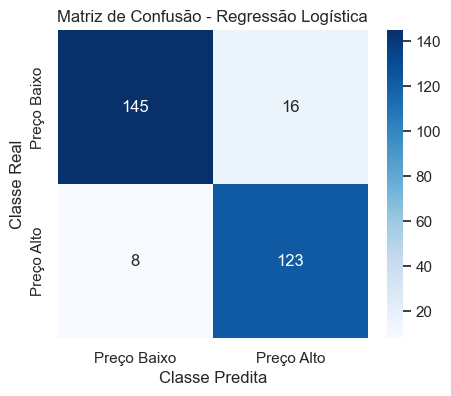

In [17]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Preço Baixo', 'Preço Alto'], yticklabels=['Preço Baixo', 'Preço Alto'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.show()

O gráfico acima apresenta a Matriz de Confusão para o modelo de validação da Regressão Logística, permitindo mapear os acertos e erros exatos do classificador ao prever as faixas de preço das 292 casas do conjunto de teste:

1. **Acertos Reais (Diagonal Principal):**
   * **Verdadeiros Negativos (145 casas):** O modelo classificou corretamente 145 imóveis como sendo de **Preço Baixo**.
   * **Verdadeiros Positivos (123 casas):** O modelo identificou com precisão 123 imóveis que pertenciam de fato à categoria de **Preço Alto**.
   * Ao somarmos esses dois quadrantes ($145 + 123 = 268$), vemos que o modelo tomou a decisão correta em **268 das 292 casas**, o que reflete a excelente taxa de Acurácia global de **91,78%** calculada anteriormente.

2. **Análise dos Erros (Diagonal Secundária):**
   * **Falsos Positivos (16 casas):** Em apenas 16 ocasiões o modelo previu que a casa seria de "Preço Alto", mas na realidade ela era de "Preço Baixo". No mercado imobiliário, isso indica imóveis supervalorizados por alguma característica específica não capturada.
   * **Falsos Negativos (8 casas):** O modelo cometeu o erro de classificar 8 casas como de "Preço Baixo" quando na verdade elas eram de "Preço Alto". Esse erro foi extremamente baixo (apenas 8 ocorrências), justificando o ótimo índice de **Recall (93,89%)** do modelo.

**Conclusão:** A matriz de confusão comprova visualmente a alta confiabilidade do modelo. O erro é marginal e muito bem distribuído, demonstrando que o classificador não possui viés de favoritismo por nenhuma das classes e está pronto para ser utilizado como uma ferramenta segura de apoio à triagem de faixas de preço de imóveis.

In [18]:
print("=========================================================================")
print("                   CONSOLIDAÇÃO FINAL DE MÉTRICAS                       ")
print("=========================================================================")
print(f" [Supervisionado - Regressão Linear Múltipla]: R² Score = {r2_reg:.4f}")
print(f" [Supervisionado - Regressão Logística]:        Acurácia = {acc_clf:.4f}")
print(f" [Não Supervisionado - K-Means Clustered]:      Número de Clusters = 3")
print(f" [Não Supervisionado - Redução PCA]:            Variância Explicada = {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f" [Não Supervisionado - LOF Outliers]:          Casas identificadas como discrepantes = {num_outliers}")
print("=========================================================================")

                   CONSOLIDAÇÃO FINAL DE MÉTRICAS                       
 [Supervisionado - Regressão Linear Múltipla]: R² Score = 0.7931
 [Supervisionado - Regressão Logística]:        Acurácia = 0.9178
 [Não Supervisionado - K-Means Clustered]:      Número de Clusters = 3
 [Não Supervisionado - Redução PCA]:            Variância Explicada = 59.79%
 [Não Supervisionado - LOF Outliers]:          Casas identificadas como discrepantes = 30
